In [13]:
import numpy as np
import matplotlib.pyplot as plt


# Ejercicio 1

In [ ]:
def euler_un_paso(f1,f2, y0, t0, h): 
	return y0 + h * np.array([f1(t0, y0), f2(t0, y0)])

def correr_metodo(f1,f2, y0, t0, tf, h, method=euler_un_paso): #correr cualquier método de paso. viene de mi hoja de fórmulas
	t = np.arange(t0, tf + h, h)
	y = [y0]
	[y.append(method(f1,f2, y[-1], t[i-1], h)) for i in range(1, len(t))]
	print(y)
	return t, np.array(y).T
	
def funcion1(t, y_vec):
	return y_vec[1] #esto es theta_prima. -> theta_{k+1}= theta_k +h theta_prima_k

def funcion2(t, y_vec, g=10, L=10):
	return -np.sin(y_vec[0])*g/L #esto es la derivada de theta_prima

def funcion(f1, f2):
	return np.array([f1,f2])



## Inciso b)

[array([1.04719755, 0.        ]), array([ 1.04719755e+00, -8.66025404e-04]), array([ 1.04719669, -0.00173205]), array([ 1.04719495, -0.00259808]), array([ 1.04719236, -0.0034641 ]), array([ 1.04718889, -0.00433012]), array([ 1.04718456, -0.00519614]), array([ 1.04717936, -0.00606216]), array([ 1.0471733 , -0.00692818]), array([ 1.04716637, -0.00779419]), array([ 1.04715858, -0.0086602 ]), array([ 1.04714992, -0.00952621]), array([ 1.04714039, -0.01039221]), array([ 1.04713   , -0.01125821]), array([ 1.04711874, -0.0121242 ]), array([ 1.04710662, -0.01299018]), array([ 1.04709363, -0.01385616]), array([ 1.04707977, -0.01472214]), array([ 1.04706505, -0.0155881 ]), array([ 1.04704946, -0.01645406]), array([ 1.04703301, -0.01732001]), array([ 1.04701569, -0.01818596]), array([ 1.0469975 , -0.01905189]), array([ 1.04697845, -0.01991782]), array([ 1.04695853, -0.02078373]), array([ 1.04693775, -0.02164964]), array([ 1.0469161 , -0.02251553]), array([ 1.04689358, -0.02338142]), array([ 1.046

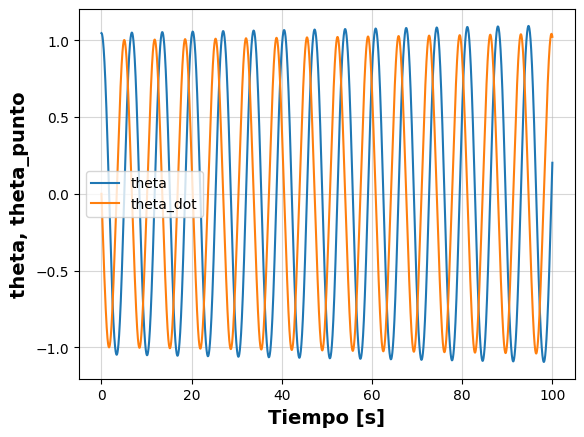

In [101]:
#condiciones iniciales:
theta_0, theta_dot_0 = np.pi/3, 0
cond_ini= np.array([theta_0, theta_dot_0])
h= 0.001
tf=100
tiempo_array = np.arange(0,tf, h)

#plt theta y theta dot (se que no tienen las mismas unidades pero los grafico juntos)
tiempo, resultados = correr_metodo(funcion1, funcion2, cond_ini, 0, tf, h)
plt.plot(tiempo, resultados[0], label = 'theta')
plt.plot(tiempo, resultados[1], label = 'theta_dot')
plt.xlabel('Tiempo [s]', fontsize = 14, fontweight = 'bold')
plt.ylabel('theta, theta_punto',fontsize = 14, fontweight = 'bold')
plt.grid(alpha=.5)
plt.legend()
plt.show()


### Diagrama de fases

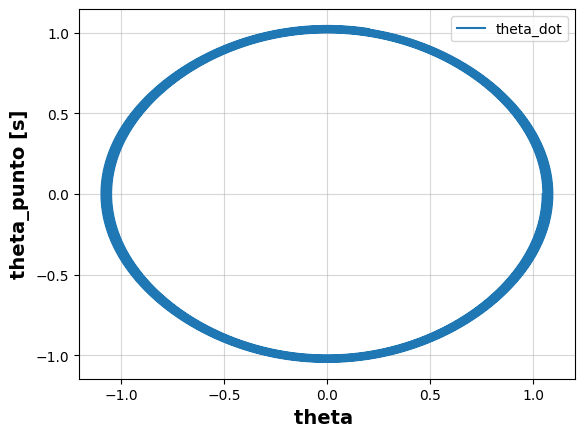

In [102]:
plt.plot(resultados[0], resultados[1], label = 'theta_dot')
plt.xlabel('theta ', fontsize = 14, fontweight = 'bold')
plt.ylabel('theta_punto [s]',fontsize = 14, fontweight = 'bold')
plt.grid(alpha=.5)
plt.legend()
plt.show()

### Energía

Parecería no conservarse (pues no es una constante). Lo probé para un $h$ muy pequeño y tambén oscila.

En el problema contínuo sí debería conservarse, pues\
$\frac{dE}{dt} = \dot{\theta} \ddot{\theta} mL^2 + mg \sin{(\theta)} \dot{\theta} = 0  $ si vale Newton (nuestra ec diferencial.)

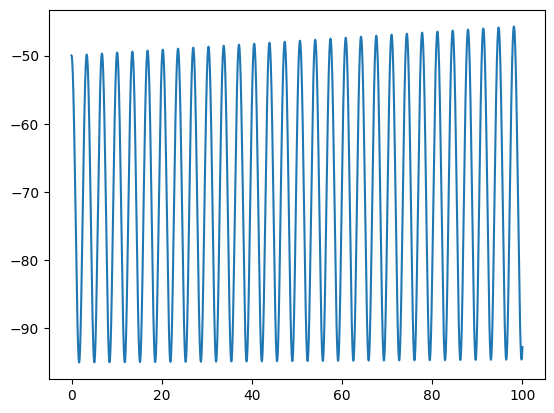

In [106]:
theta, theta_punto = resultados
m=1
L=10
E = m*(L*theta_punto**2)/2 - m*10*L*np.cos(theta)
plt.plot(tiempo, E)


## Inciso c)

Discetización de segundo orden con $\theta_0=\theta_1= \pi /3$

In [ ]:
def matriz_tridiag(N):
	matriz = -2*np.eye(N+1)

	for i in range(1,N+1):
		if i != N:
			matriz[i,i+1] = 1
		if i!=1:
			matriz[i,i-1] = 1
	matriz[0,0] =1
	matriz[1,1] =1 
	return matriz	

g=10
L=10
h_nuevo=0.1
t_array =np.arange(0,100 + 2*h_nuevo, h_nuevo)
N= len(t_array[:-1])
A = matriz_tridiag(N)
r= h**2 * g/L
b = -r*np.sin(theta)

#display(matriz_tridiag(N))

array([[ 1., -0., -0., ..., -0., -0., -0.],
       [-0.,  1.,  1., ..., -0., -0., -0.],
       [-0.,  1., -2., ..., -0., -0., -0.],
       ...,
       [-0., -0., -0., ..., -2.,  1., -0.],
       [-0., -0., -0., ...,  1., -2.,  1.],
       [-0., -0., -0., ..., -0.,  1., -2.]], shape=(1002, 1002))

In [182]:
def metodo_2(theta_k,theta_k_1, h=0.1, g=10, L=10):
    return 2*theta_k - theta_k_1 - g/L * np.sin(theta_k)

def correr_metodo_2(theta_k,theta_k_1, t0, tf, h=0.1, method=metodo_2): #correr cualquier método de paso. viene de mi hoja de fórmulas
	t = np.arange(t0, tf + h, h)
	tita = [theta_k,theta_k_1]

	for i in range(1, len(t)):

		tita.append(method(tita[-1],tita[-2], t[i-1], h)) 
	return t, np.array(tita).T

t, theta_metodo2 = correr_metodo_2(np.pi/3, np.pi/3,0, 100)
theta_metodo2

array([1.04719755, 1.04719755, 1.0385373 , ..., 0.40058961, 0.49038653,
       0.57547379], shape=(1002,))

Text(0.5, 0, 't')

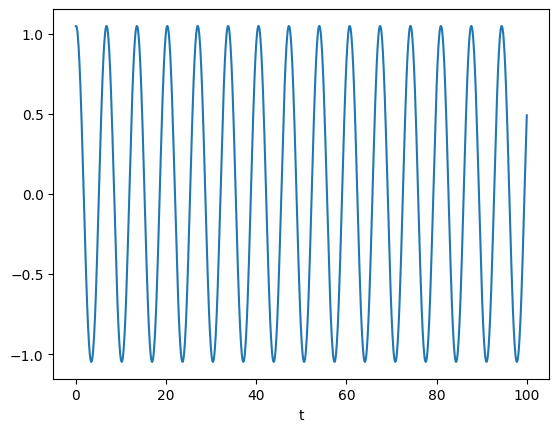

In [184]:
plt.plot(t, theta_metodo2[:len(t)])
plt.xlabel('t')

# Ejercicio 2
lamentablemente fui vencido por tiempo

In [ ]:
def LU_gauss_sin_pivot(A, redondeo=3):
	n = A.shape[0]
	U, L = A.copy(), np.eye(n)
	for i in range(n):
		for j in range(i+1, n):
			L[j, i] = np.round(U[j, i] / U[i, i], redondeo)
			U[j] = np.round(U[j] - L[j, i] * U[i], redondeo)
	return L, U

def matriz_pentadiagonal(h=0.1):
    t= np.arange(0,1, h)
    matriz = np.zeros((N+1, N+1))
    for i in range(1,N):
        matriz[i,i] = 6
        if i >=2:
            matriz[i,i-2] = 1
        if i >=1:
            matriz[i,i-1] = -4
        if i <= N-1:
            matriz[i,i+1] = -4
        if i <= N-2:
            matriz[i,i+2] = 1
    matriz[0,0] = 1
    matriz[1,1] = 1
    matriz[-1,-1] = 1
    matriz[-2,-2] = 1
    return matriz

def matriz_penta(N):
	diag_0= np.random.random(N)*10
	diag_1 = np.random.random(N-1)
	diag_2 = np.random.random(N-2)
	diag_1_ = np.random.random(N-1)
	diag_2_= np.random.random(N-2)
	diagonales = [diag_1, diag_2, diag_1_, diag_2_]
	matriz = np.zeros((N,N))
	print(diag_0)
	for i in range(0,N):

		for j in range(1,N-2):
			if i != N-2 and j==i+1:
				matriz[i,j] = diag_1[j]
			if	i != N-3 and j==i+2: 
				matriz[i,j] = diag_2[j]
			#if i!=1 and j==i-1:
			if j==i-1 and i!=0:
				matriz[j,i] = diag_1_[j]
			if i!=1 and j==i-2:
				matriz[i,j] = diag_2_[j]
		matriz[i,i]=diag_0[i]

	matriz[0,0]=diag_0[0]
	return matriz

def matrix_penta2(f):
	n=len(f)
	N=n
	A=np.zeros((N,N))
	diag_0= np.random.random(N)*10
	diag_1 = np.random.random(N-1)
	diag_2 = np.random.random(N-2)
	diag_1_ = np.random.random(N-1)
	diag_2_= np.random.random(N-2)
	for i in range(N):
		if i>0:
			A[i,i]= diag_0[i]
		if i>1:
			A[i,i+1] = diag_1[i]
			A[i,i-1] = diag_1_[i]
		if i>2:
			A[i,i+2] = diag_2[i]
			A[i,i-2] = diag_2_[i]
	print(A)

	identidad = np.ones(n,n)
	A_cmb= A
	f_cmb= f
	for k in range(n-1):
		if A_cmb[k,k] !=0:
			tau_k=A_cmb[k+1,k]/A_cmb[k,k]
			cer = np.zeros(n,n)
			cer[k+1:,k] = tau_k
			Mk= identidad@cer
			A_cmb = Mk@A_cmb
			f_cmb = Mk@f_cmb
		else:
			print('no podes pivotear')
			break



In [ ]:
def matrix_penta2(f):
	n=len(f)
	N=n
	A=np.zeros((N,N))
	diag_0= np.random.random(N)*10
	diag_1 = np.random.random(N-1)
	diag_2 = np.random.random(N-2)
	diag_1_ = np.random.random(N-1)
	diag_2_= np.random.random(N-2)
	
	
	

# Ejercicio 3
pongo todas condiciones en 0

In [241]:
def matriz_pentadiagonal(h=0.1):
    t= np.arange(0,1, h)
    matriz = np.zeros((N+1, N+1))
    for i in range(1,N):
        matriz[i,i] = 6
        if i >=2:
            matriz[i,i-2] = 1
        if i >=1:
            matriz[i,i-1] = -4
        if i <= N-1:
            matriz[i,i+1] = -4
        if i <= N-2:
            matriz[i,i+2] = 1
    matriz[0,0] = 1
    matriz[1,1] = 1
    matriz[1,0], matriz[1,2], matriz[-2,-1]=0,0,0
    matriz[-1,-1] = 1
    matriz[-2,-2] = 1

    return matriz

matriz = matriz_pentadiagonal(10)
print(matriz)


[[ 1.  0.  0. ...  0.  0.  0.]
 [ 0.  1.  0. ...  0.  0.  0.]
 [ 1. -4.  6. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  6. -4.  1.]
 [ 0.  0.  0. ... -4.  1.  0.]
 [ 0.  0.  0. ...  0.  0.  1.]]


0

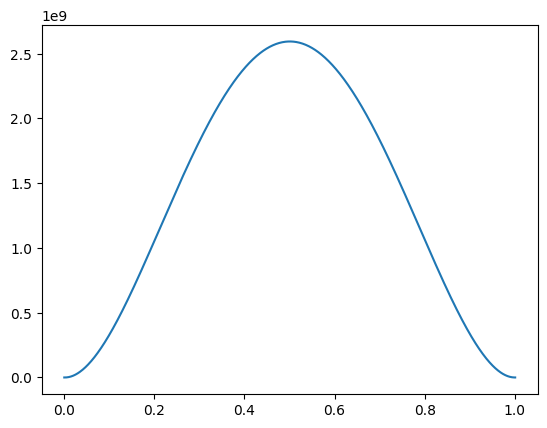

In [ ]:
def problema_contornos(A): #ejemplo medio random que podría volar
	
	N = A.shape[0]
	t= np.linspace(0,1+1/N,N)
	b = np.ones(N)
	b[0], b[1] =0,0
	b[-1] = 0
	b[-2]=0
	x= np.linalg.solve(A,b)
	return t,x

#no llego a hacerlo bonito
t, x=problema_contornos(matriz)
plt.plot(t,x)
0